<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_4_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 4, Metriche di Valutazione

In questo notebook esploriamo le metriche che usiamo per misurare quanto bene un modello impara.  
Le vedremo in azione su dati sintetici, così puoi concentrarti sui concetti senza distrarti con la pulizia del dataset.

Le tre famiglie che copriremo:
- **Metriche di Regressione**: MSE, RMSE, MAE, R², MAPE
- **Metriche di Classificazione**: Accuracy, Precision, Recall, F1, AUC-ROC, Log Loss
- **Metriche di Clustering**: Inertia, Silhouette Score, Davies-Bouldin Index


## 0. Setup, importare le librerie

In [ ]:
%pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Metriche di regressione
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score, mean_absolute_percentage_error
)

# Metriche di classificazione
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)

# Metriche di clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

np.random.seed(42)
print('Setup completato!')

Setup completato!


---
## A. Metriche di Regressione

Le metriche di regressione confrontano il valore previsto dal modello con il valore reale.  
Creiamo un dataset sintetico di prezzi di appartamenti (in migliaia di euro) e simuliamo le previsioni di un modello.

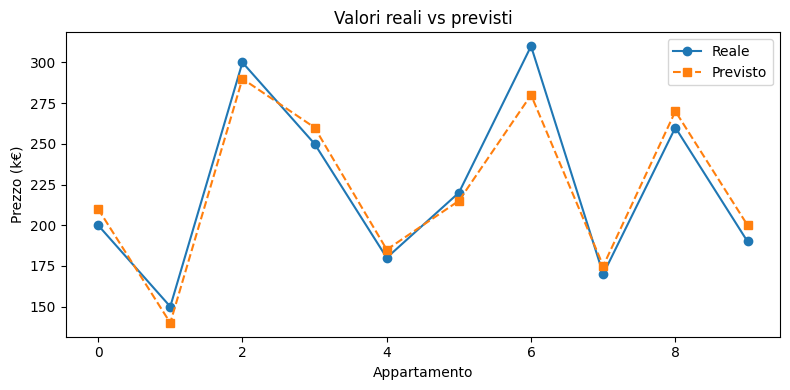

In [3]:
# Valori reali: prezzi di 10 appartamenti (in migliaia di euro)
y_true = np.array([200, 150, 300, 250, 180, 220, 310, 170, 260, 190], dtype=float)

# Valori predetti dal modello (abbastanza buoni, ma non perfetti)
y_pred = np.array([210, 140, 290, 260, 185, 215, 280, 175, 270, 200], dtype=float)

# Visualizziamo reale vs previsto
plt.figure(figsize=(8, 4))
plt.plot(y_true, 'o-', label='Reale')
plt.plot(y_pred, 's--', label='Previsto')
plt.xlabel('Appartamento')
plt.ylabel('Prezzo (k€)')
plt.title('Valori reali vs previsti')
plt.legend()
plt.tight_layout()
plt.show()

### MSE e RMSE

L'MSE penalizza gli errori grandi in modo sproporzionato (quadrato delle differenze).  
L'RMSE è la sua radice quadrata: riporta il risultato nella stessa unità dei dati originali, molto più interpretabile.

In [9]:
mse  = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print(f'MSE = {mse:.2f} (unità: euro² -> difficile da interpretare)')
print(f'RMSE = {rmse:.2f} k€ -> in media il modello sbaglia di {rmse:.1f}k€')

MSE = 157.50 (unità: euro² -> difficile da interpretare)
RMSE = 12.55 k€ -> in media il modello sbaglia di 12.5k€


### MAE

La MAE tratta tutti gli errori in modo lineare: un errore doppio conta il doppio, senza penalizzazioni aggiuntive.  
È più robusta agli outlier rispetto all'RMSE. Se MAE ≪ RMSE, ci sono alcuni errori molto grandi che alzano l'RMSE.

In [11]:
mae = mean_absolute_error(y_true, y_pred)
print(f'MAE = {mae:.2f} k€ -> in media il modello sbaglia di {mae:.1f}k€')

# Aggiungiamo un outlier estremo e vediamo l'effetto su RMSE vs MAE
y_pred_outlier = y_pred.copy()
y_pred_outlier[2] = 500  # previsione assurda per il terzo appartamento

print(f'\nCon un outlier estremo:')
print(f'RMSE = {root_mean_squared_error(y_true, y_pred_outlier):.1f} k€ (schizza su)')
print(f'MAE = {mean_absolute_error(y_true, y_pred_outlier):.1f} k€ (aumenta, ma molto meno)')

MAE = 10.50 k€ -> in media il modello sbaglia di 10.5k€

Con un outlier estremo:
RMSE = 64.4 k€ (schizza su)
MAE = 29.5 k€ (aumenta, ma molto meno)


### R² e MAPE

In [13]:
r2   = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f'R² = {r2:.3f} -> il modello spiega il {r2*100:.1f}% della variabilità dei dati')
print(f'MAPE = {mape*100:.2f}% -> in media il modello sbaglia del {mape*100:.1f}% rispetto al valore reale')

# R² di un modello che prevede sempre la media (il peggiore possibile senza essere peggio della media)
y_mean = np.full_like(y_true, y_true.mean())
print(f'\nR² del predittore costante (sempre la media) = {r2_score(y_true, y_mean):.1f}')

R² = 0.942 -> il modello spiega il 94.2% della variabilità dei dati
MAPE = 4.58% -> in media il modello sbaglia del 4.6% rispetto al valore reale

R² del predittore costante (sempre la media) = 0.0


---
## B. Metriche di Classificazione

Simuliamo un problema medico binario: rilevare se un paziente ha una malattia (1 = malato, 0 = sano).  
Su 20 pazienti, 7 sono realmente malati. Vediamo come si comportano le diverse metriche.

In [15]:
# Etichette reali (7 malati su 20)
y_true_cls = np.array([1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,1,0])

# Previsioni del modello
y_pred_cls = np.array([1,0,1,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,1,0])

# Probabilità grezze (servono per AUC-ROC e Log Loss)
y_scores   = np.array([0.9,0.1,0.8,0.2,0.3,0.4,0.15,0.85,0.6,0.05,
                        0.75,0.2,0.1,0.95,0.3,0.1,0.45,0.05,0.7,0.25])

print(f'Pazienti totali : {len(y_true_cls)}')
print(f'Malati reali : {y_true_cls.sum()}')
print(f'Predetti malati : {y_pred_cls.sum()}')

Pazienti totali : 20
Malati reali : 8
Predetti malati : 7


### Matrice di Confusione

La matrice di confusione è il punto di partenza: mostra quanti TP, TN, FP e FN ha prodotto il modello.  
Le celle sulla diagonale sono le previsioni corrette, quelle fuori diagonale sono gli errori.

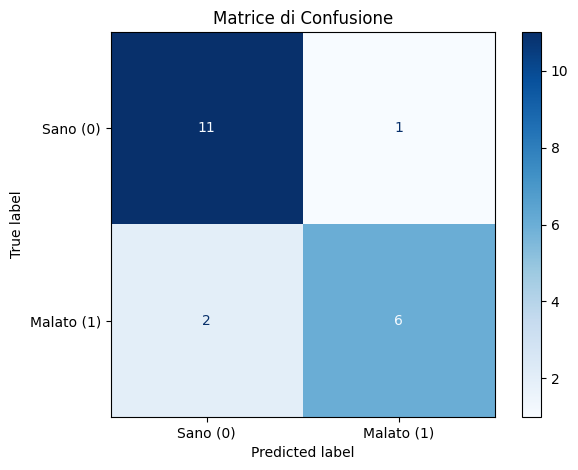

TP (malato predetto malato)  = 6  ✅
TN (sano predetto sano)      = 11  ✅
FP (sano predetto malato)    = 1  ❌ falso allarme
FN (malato predetto sano)    = 2  ❌ caso pericoloso!


In [16]:
cm = confusion_matrix(y_true_cls, y_pred_cls)

disp = ConfusionMatrixDisplay(cm, display_labels=['Sano (0)', 'Malato (1)'])
disp.plot(cmap='Blues')
plt.title('Matrice di Confusione')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP (malato predetto malato)  = {tp}  ✅')
print(f'TN (sano predetto sano)      = {tn}  ✅')
print(f'FP (sano predetto malato)    = {fp}  ❌ falso allarme')
print(f'FN (malato predetto sano)    = {fn}  ❌ caso pericoloso!')

### Accuracy, Precision, Recall, F1

In [ ]:
acc  = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls)
rec  = recall_score(y_true_cls, y_pred_cls)
f1   = f1_score(y_true_cls, y_pred_cls)

print(f'Accuracy  = {acc:.2f} -> {acc*100:.0f}% di previsioni corrette in totale')
print(f'Precision = {prec:.2f} -> quando dice "malato", ha ragione nel {prec*100:.0f}% dei casi')
print(f'Recall = {rec:.2f} -> trova il {rec*100:.0f}% dei malati reali')
print(f'F1-Score  = {f1:.2f} -> media armonica di Precision e Recall')

# Perché l'accuracy da sola inganna?
# Creiamo un modello stupido che dice sempre "sano"
y_always_sano = np.zeros_like(y_true_cls)
print(f'\nModello stupido: dice sempre Sano')
print(f'Accuracy = {accuracy_score(y_true_cls, y_always_sano):.2f}  (sembra decente...)')
print(f'Recall = {recall_score(y_true_cls, y_always_sano):.2f}  (non trova nessun malato!)')
#Questo modello sarebbe identico ad un print(0)...

Accuracy  = 0.85 -> 85% di previsioni corrette in totale
Precision = 0.86 -> quando dice "malato", ha ragione nel 86% dei casi
Recall = 0.75 -> trova il 75% dei malati reali
F1-Score  = 0.80 -> media armonica di Precision e Recall

Modello stupido: dice sempre Sano
Accuracy = 0.60  (sembra decente...)
Recall = 0.00  (non trova nessun malato!)


### Il trade-off tra Precision e Recall

Il modello assegna una probabilità a ogni esempio. Abbassando la soglia aumenta il Recall (trova più malati) ma scende la Precision (più falsi allarmi). Alzando la soglia succede il contrario.

In [20]:
soglie   = [0.3, 0.5, 0.7]
labels   = ['Soglia 0.3 (più sensibile)', 'Soglia 0.5 (default)', 'Soglia 0.7 (più prudente)']

print(f'{"Soglia":<8} {"Precision":>10} {"Recall":>8} {"F1":>8}')
for soglia in soglie:
    y_p = (y_scores >= soglia).astype(int)
    p   = precision_score(y_true_cls, y_p, zero_division=0)
    r   = recall_score(y_true_cls, y_p, zero_division=0)
    f   = f1_score(y_true_cls, y_p, zero_division=0)
    print(f'{soglia:<8.1f} {p:>10.2f} {r:>8.2f} {f:>8.2f}')

Soglia    Precision   Recall       F1
0.3            0.73     1.00     0.84
0.5            0.86     0.75     0.80
0.7            1.00     0.75     0.86


### AUC-ROC e Log Loss

L'AUC-ROC valuta il modello su tutte le soglie possibili: è ottima per confrontare modelli diversi tra loro.  
La Log Loss penalizza le previsioni sbagliate fatte con alta confidenza.

AUC-ROC = 0.979 (1.0 = perfetto, 0.5 = casuale)
Log Loss = 0.292 (più bassa è, meglio è)


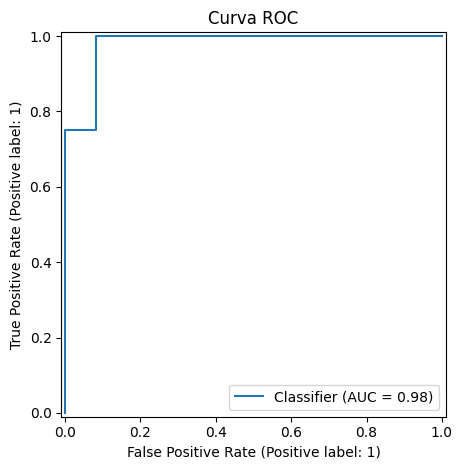

In [21]:
auc = roc_auc_score(y_true_cls, y_scores)
ll  = log_loss(y_true_cls, y_scores)

print(f'AUC-ROC = {auc:.3f} (1.0 = perfetto, 0.5 = casuale)')
print(f'Log Loss = {ll:.3f} (più bassa è, meglio è)')

# Curva ROC
RocCurveDisplay.from_predictions(y_true_cls, y_scores)
plt.title('Curva ROC')
plt.tight_layout()
plt.show()

### Classification Report

Una sola riga di codice per avere il quadro completo: Precision, Recall, F1 e il numero di esempi per ogni classe.

In [22]:
print(classification_report(y_true_cls, y_pred_cls, target_names=['Sano', 'Malato']))

              precision    recall  f1-score   support

        Sano       0.85      0.92      0.88        12
      Malato       0.86      0.75      0.80         8

    accuracy                           0.85        20
   macro avg       0.85      0.83      0.84        20
weighted avg       0.85      0.85      0.85        20



---
## C. Metriche di Clustering

Nel clustering non abbiamo etichette reali: valutiamo la qualità intrinseca dei cluster trovati.  
Generiamo un dataset con 3 gruppi ben separati e usiamo KMeans.

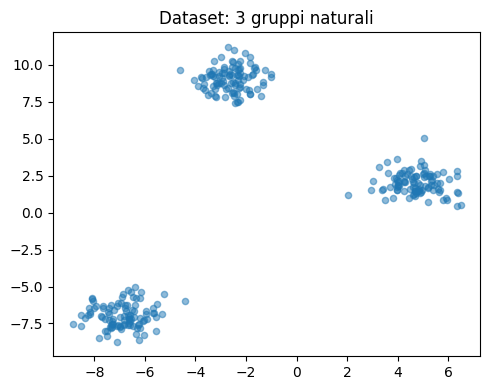

In [23]:
# Dataset sintetico con 3 cluster ben separati
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=20)
plt.title('Dataset: 3 gruppi naturali')
plt.tight_layout()
plt.show()

### Inertia e Elbow Method

L'inertia misura quanto i punti sono compatti intorno al loro centroide.  
Diminuisce sempre all'aumentare di k: il "gomito" della curva indica il k ottimale.

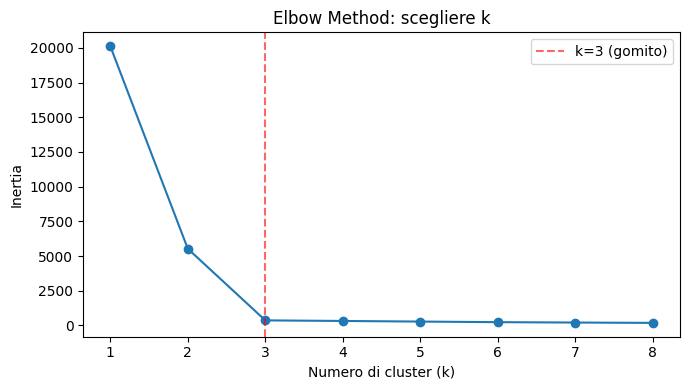

In [24]:
inertias = []
k_range  = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'o-')
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (gomito)')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: scegliere k')
plt.legend()
plt.tight_layout()
plt.show()

### Silhouette Score e Davies-Bouldin Index

Silhouette: vicino a 1 = cluster ben separati, vicino a 0 = confine tra cluster, negativo = cluster sbagliato.  
Davies-Bouldin: più basso è meglio. Entrambi si usano insieme per una valutazione più robusta.

In [26]:
print(f'{"k":<5} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print('-' * 35)

for k in range(2, 7):
    km     = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels)
    db     = davies_bouldin_score(X, labels)
    marker = '  <-- ottimo' if k == 3 else ''
    print(f'{k:<5} {sil:>12.3f} {db:>16.3f}{marker}')

k       Silhouette   Davies-Bouldin
-----------------------------------
2            0.721            0.416
3            0.878            0.170  <-- ottimo
4            0.693            0.635
5            0.498            0.973
6            0.327            1.154


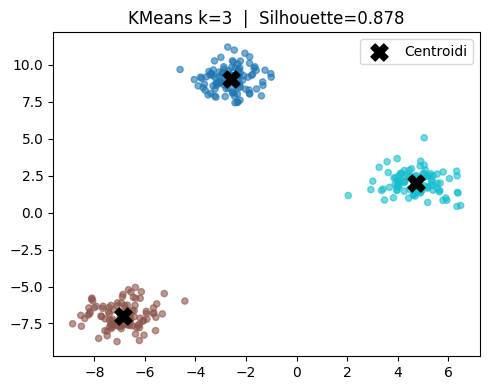

In [27]:
# Visualizziamo i cluster con k=3 (il migliore)
km_best = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_best = km_best.fit_predict(X)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_best, cmap='tab10', alpha=0.6, s=20)
plt.scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
            c='black', marker='X', s=150, label='Centroidi')
plt.title(f'KMeans k=3  |  Silhouette={silhouette_score(X, labels_best):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

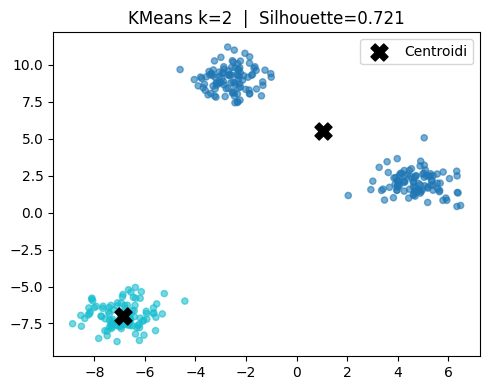

In [29]:
# Visualizziamo i cluster con k=2
# Notiamo che con k=2 la Silhouette è più bassa e i cluster sono meno ben separati
km_best = KMeans(n_clusters=2, random_state=42, n_init='auto')
labels_best = km_best.fit_predict(X)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_best, cmap='tab10', alpha=0.6, s=20)
plt.scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
            c='black', marker='X', s=150, label='Centroidi')
plt.title(f'KMeans k=2  |  Silhouette={silhouette_score(X, labels_best):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Andiamo al capitolo 5: Regressione!!!